
# Beer 실험: Train PCA(231 축 생성 → 0분산 축 제거) + 단일 PC(1D) 선형회귀로 관능(50개) 예측 랭킹

## 실험 목표(요청사항 그대로 구현)
- 데이터: 화학 231개(X)로 관능 50개(Y)
- 1개의 관능(target)씩 독립적으로 실험을 수행 → 총 50번 반복
- Train(175)으로 PCA를 수행하여 **231개의 직교 축(고유벡터)** 생성
- 각 축의 **분산/분산비율(EVR)** 계산
- 분산이 0(또는 아주 작은 값)인 축 제거 → 남은 축들로 train 데이터를 (수치오차 제외) **100% 재구성 가능**해야 함
  - ⚠️ Train이 175개면, 센터링된 데이터의 rank ≤ 174이므로 0-분산 축이 많이 생기는 것은 정상입니다.
- 남은 PC 축들 각각에 대해:
  - Train/Test를 해당 PC 1개 축으로만 투영(사영) → 1D 값 z_j
  - `y ~ a*z_j + b` **1대1 선형회귀** 학습
  - Test 기준 성능(RMSE, R² 등)으로 PC들을 **가장 잘 예측하는 순서대로 랭킹**
- 이 과정을 50개 관능 변수 각각에 대해 반복

## 출력물
`OUT_DIR/RUN_TAG/` 아래에 저장됩니다.
- `pca_axes_{RUN_TAG}.npz` : train 기준 mean/std, eigenvectors(231), eigenvalues 등
- `pca_explained_variance_{RUN_TAG}.csv` : PC별 분산/분산비율
- `evr_{RUN_TAG}.png`, `cumevr_{RUN_TAG}.png`
- `recon_check_{RUN_TAG}.csv` : train 재구성 오차 확인
- `single_pc_results_all_targets_{RUN_TAG}.csv` : (50×PC개수) 전체 결과
- `top_pc_per_target_{RUN_TAG}.csv` : target별 상위 N개의 PC만 요약

---


In [1]:

import os
import datetime as dt
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [2]:

# =========================================================
# 0) 설정 (필요한 것만 수정)
# =========================================================

# ---- 데이터 경로 ----
DATA_XLSX_PATH     = r"/home/a202192020/맥주데이터실험/data/Supplemental Files and Figure source files.xlsx"
FALLBACK_XLSX_PATH = r"/home/a202192020/맥주데이터실험/data/Supplemental Files and Figure source files.xlsx"

CHEM_SHEET = "Supplementary File S1"
SENS_SHEET = "Supplementary File S4"

# ---- 분할 ----
TEST_SIZE = 0.30
RANDOM_STATE = 0  # 논문 재현과 맞추려면 0 권장. 원하는 seed로 바꿔도 됨.
STRATIFY_COL = "tasting_category_fine"

# ---- PCA 전처리 ----
STANDARDIZE_BEFORE_PCA = True   # True면 상관(표준화된 공분산) 기준 PCA에 해당
EIG_TOL = 1e-12                 # "0 분산(고유값=0)" 판정 임계값

# ---- 결과 저장 ----
OUT_DIR = r"/home/a202192020/맥주데이터실험/pca/0223/pca_y1/output"
RUN_TAG = dt.datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_DIR = os.path.join(OUT_DIR, RUN_TAG)
os.makedirs(RUN_DIR, exist_ok=True)

# ---- 출력 파일 ----
NPZ_PATH        = os.path.join(RUN_DIR, f"pca_axes_{RUN_TAG}.npz")
EV_CSV_PATH     = os.path.join(RUN_DIR, f"pca_explained_variance_{RUN_TAG}.csv")
EVR_PNG_PATH    = os.path.join(RUN_DIR, f"evr_{RUN_TAG}.png")
CUMEVR_PNG_PATH = os.path.join(RUN_DIR, f"cumevr_{RUN_TAG}.png")
RECON_CSV_PATH  = os.path.join(RUN_DIR, f"recon_check_{RUN_TAG}.csv")

ALLRES_CSV_PATH = os.path.join(RUN_DIR, f"single_pc_results_all_targets_{RUN_TAG}.csv")
TOPRES_CSV_PATH = os.path.join(RUN_DIR, f"top_pc_per_target_{RUN_TAG}.csv")

TOP_N_PER_TARGET = 15   # target별 상위 몇 개 PC를 요약 저장할지

print("RUN_DIR:", RUN_DIR)


RUN_DIR: /home/a202192020/맥주데이터실험/pca/0223/pca_y1/output/20260223_174342


In [ ]:

# =========================================================
# 1) Excel 로드 + merge
# =========================================================
xlsx_path = DATA_XLSX_PATH
if not os.path.exists(xlsx_path):
    if os.path.exists(FALLBACK_XLSX_PATH):
        xlsx_path = FALLBACK_XLSX_PATH
        print("⚠️ using fallback:", xlsx_path)
    else:
        raise FileNotFoundError(f"Excel not found:\n- {DATA_XLSX_PATH}\n- {FALLBACK_XLSX_PATH}")

chem_df = pd.read_excel(xlsx_path, sheet_name=CHEM_SHEET)
sens_df = pd.read_excel(xlsx_path, sheet_name=SENS_SHEET)

META_COLS = ["beer", "beer_id", "tasting_category_fine"]

df = chem_df.merge(sens_df, on=META_COLS, how="inner", validate="one_to_one")
print("merged df:", df.shape)

feature_cols = [c for c in chem_df.columns if c not in META_COLS]
target_cols  = [c for c in sens_df.columns if c not in META_COLS]

print("#features:", len(feature_cols), " #targets:", len(target_cols))
assert len(feature_cols) == 231, f"features={len(feature_cols)} (expected 231)"
assert len(target_cols)  == 50,  f"targets={len(target_cols)} (expected 50)"


merged df: (250, 284)
#features: 231  #targets: 50


In [ ]:

# =========================================================
# 2) Train/Test split (175/75) + style stratify
# =========================================================
train_df, test_df = train_test_split(
    df,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    shuffle=True,
    stratify=df[STRATIFY_COL]
)

X_train = train_df[feature_cols].copy()
X_test  = test_df[feature_cols].copy()

Y_train = train_df[target_cols].copy()
Y_test  = test_df[target_cols].copy()

print("train:", X_train.shape, Y_train.shape, "test:", X_test.shape, Y_test.shape)

# 결측치: train 평균으로 대체 (누수 방지)
impute_means = X_train.mean(axis=0)
X_train = X_train.fillna(impute_means)
X_test  = X_test.fillna(impute_means)

print("missing train:", int(X_train.isna().sum().sum()), "missing test:", int(X_test.isna().sum().sum()))


train: (175, 231) (175, 50) test: (75, 231) (75, 50)
missing train: 0 missing test: 0


In [ ]:

# =========================================================
# 3) Train으로 PCA 축(231개) 생성: 공분산행렬 고유분해(eigh)
#    - 231개의 직교 축 생성
#    - 0(또는 매우 작은) 분산 축 제거
# =========================================================

Xtr = X_train.values.astype(float)
Xte = X_test.values.astype(float)

# (A) 센터링/표준화 파라미터는 train에서만 추정
mu = Xtr.mean(axis=0)
Xtr_c = Xtr - mu
Xte_c = Xte - mu

if STANDARDIZE_BEFORE_PCA:
    # 표준편차 0인 컬럼 보호(상수 feature)
    sigma = Xtr_c.std(axis=0, ddof=0)
    sigma_safe = sigma.copy()
    sigma_safe[sigma_safe == 0] = 1.0
    Xtr_cs = Xtr_c / sigma_safe
    Xte_cs = Xte_c / sigma_safe
else:
    sigma_safe = np.ones(Xtr_c.shape[1], dtype=float)
    Xtr_cs = Xtr_c
    Xte_cs = Xte_c

n_train, p = Xtr_cs.shape
print("n_train:", n_train, "p:", p)

# (B) 공분산행렬 (p x p)
#     S = (X^T X)/(n-1)
S = (Xtr_cs.T @ Xtr_cs) / (n_train - 1)

# (C) 대칭행렬 고유분해 (오름차순) -> 내림차순으로 뒤집기
eigvals, eigvecs = np.linalg.eigh(S)
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]  # columns are eigenvectors

# 수치오차로 음수 아주 작은 값이 있을 수 있어 0으로 클립
eigvals_clipped = np.clip(eigvals, 0, None)

total_var = eigvals_clipped.sum()
evr = eigvals_clipped / total_var if total_var > 0 else np.zeros_like(eigvals_clipped)

# (D) 0-분산 축 제거
keep_mask = eigvals_clipped > EIG_TOL
k_keep = int(keep_mask.sum())

print("kept components (eig>tol):", k_keep, "/", p)
print("dropped (≈0 variance):", int((~keep_mask).sum()))

V_keep = eigvecs[:, keep_mask]               # (p, k_keep)
lam_keep = eigvals_clipped[keep_mask]        # (k_keep,)
evr_keep = evr[keep_mask]                    # (k_keep,)

# (E) projection (scores)
Z_train = Xtr_cs @ V_keep                    # (n_train, k_keep)
Z_test  = Xte_cs @ V_keep                    # (n_test, k_keep)

print("Z_train:", Z_train.shape, "Z_test:", Z_test.shape)

# (F) 저장(npz)
np.savez(
    NPZ_PATH,
    feature_cols=np.array(feature_cols, dtype=object),
    mu=mu,
    sigma=sigma_safe,
    standardize_before_pca=np.array([STANDARDIZE_BEFORE_PCA]),
    eig_tol=np.array([EIG_TOL]),
    eigvals=eigvals_clipped,
    eigvecs=eigvecs,
    keep_mask=keep_mask,
    V_keep=V_keep,
    lam_keep=lam_keep,
    evr=evr,
    evr_keep=evr_keep,
)
print("✅ saved:", NPZ_PATH)

# (G) EVR 저장(csv)
ev_df = pd.DataFrame({
    "pc_index_1based": np.arange(1, p+1),
    "eigenvalue": eigvals_clipped,
    "explained_variance_ratio": evr,
    "kept": keep_mask
})
ev_df.to_csv(EV_CSV_PATH, index=False)
print("✅ saved:", EV_CSV_PATH)


n_train: 175 p: 231
kept components (eig>tol): 174 / 231
dropped (≈0 variance): 57
Z_train: (175, 174) Z_test: (75, 174)
✅ saved: /home/a202192020/맥주데이터실험/pca/0223/pca_y1/output/20260223_174342/pca_axes_20260223_174342.npz
✅ saved: /home/a202192020/맥주데이터실험/pca/0223/pca_y1/output/20260223_174342/pca_explained_variance_20260223_174342.csv


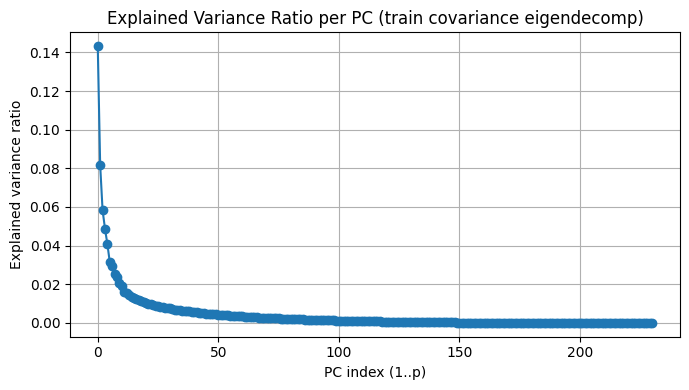

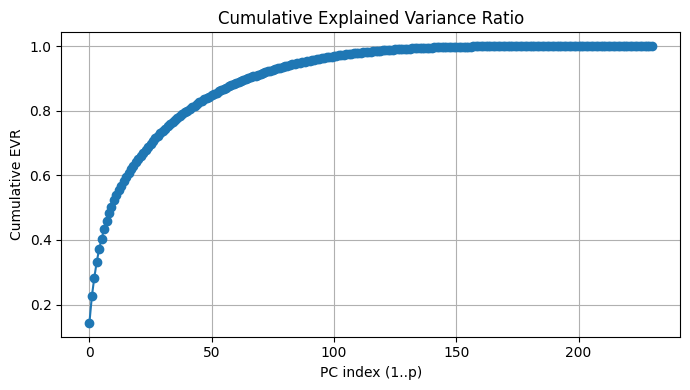

✅ saved: /home/a202192020/맥주데이터실험/pca/0223/pca_y1/output/20260223_174342/evr_20260223_174342.png
✅ saved: /home/a202192020/맥주데이터실험/pca/0223/pca_y1/output/20260223_174342/cumevr_20260223_174342.png
Reconstruction RMSE (train, raw space): 1.6404119125200864e-13
Reconstruction max abs error: 6.821210263296962e-12
✅ saved: /home/a202192020/맥주데이터실험/pca/0223/pca_y1/output/20260223_174342/recon_check_20260223_174342.csv


In [ ]:

# =========================================================
# 4) EVR plot 저장 + "정보 100% 표현(재구성)" 확인(train 기준)
# =========================================================

# EVR plot
plt.figure(figsize=(7,4))
plt.plot(evr, marker="o")
plt.title("Explained Variance Ratio per PC (train covariance eigendecomp)")
plt.xlabel("PC index (1..p)")
plt.ylabel("Explained variance ratio")
plt.grid(True)
plt.tight_layout()
plt.savefig(EVR_PNG_PATH, dpi=150)
plt.show()

# 누적 EVR
cum_evr = np.cumsum(evr)
plt.figure(figsize=(7,4))
plt.plot(cum_evr, marker="o")
plt.title("Cumulative Explained Variance Ratio")
plt.xlabel("PC index (1..p)")
plt.ylabel("Cumulative EVR")
plt.grid(True)
plt.tight_layout()
plt.savefig(CUMEVR_PNG_PATH, dpi=150)
plt.show()

print("✅ saved:", EVR_PNG_PATH)
print("✅ saved:", CUMEVR_PNG_PATH)

# ---- 재구성 체크 ----
# X_hat_cs = Z * V^T
Xtr_hat_cs = Z_train @ V_keep.T
# 역표준화 + 평균 복원
Xtr_hat = Xtr_hat_cs * sigma_safe + mu

rmse_recon = float(np.sqrt(np.mean((Xtr - Xtr_hat) ** 2)))
max_abs_err = float(np.max(np.abs(Xtr - Xtr_hat)))

recon_df = pd.DataFrame([{
    "n_train": n_train,
    "p": p,
    "k_keep": k_keep,
    "standardize_before_pca": STANDARDIZE_BEFORE_PCA,
    "eig_tol": EIG_TOL,
    "reconstruction_rmse": rmse_recon,
    "reconstruction_max_abs_err": max_abs_err,
}])
recon_df.to_csv(RECON_CSV_PATH, index=False)

print("Reconstruction RMSE (train, raw space):", rmse_recon)
print("Reconstruction max abs error:", max_abs_err)
print("✅ saved:", RECON_CSV_PATH)


In [ ]:

# =========================================================
# 5) 1대1 선형회귀: 각 target마다, 각 PC 1개로만 학습 → 랭킹
# =========================================================

def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

results = []

for t_idx, target in enumerate(target_cols, start=1):
    ytr = Y_train[target].values.astype(float)
    yte = Y_test[target].values.astype(float)

    # 각 PC를 하나씩 사용: z_j
    for j in range(k_keep):
        ztr = Z_train[:, [j]]  # (n,1)
        zte = Z_test[:,  [j]]

        model = LinearRegression()
        model.fit(ztr, ytr)

        pred_tr = model.predict(ztr)
        pred_te = model.predict(zte)

        results.append({
            "target": target,
            "pc_index_1based_kept": j + 1,            # kept 공간에서의 인덱스
            "pc_index_1based_full": int(np.where(keep_mask)[0][j] + 1),  # 원래 231 축에서의 인덱스
            "eigenvalue": float(lam_keep[j]),
            "evr": float(evr_keep[j]),
            "coef": float(model.coef_.ravel()[0]),
            "intercept": float(model.intercept_),
            "train_rmse": rmse(ytr, pred_tr),
            "train_r2": float(r2_score(ytr, pred_tr)),
            "test_rmse": rmse(yte, pred_te),
            "test_r2": float(r2_score(yte, pred_te)),
        })

    if t_idx % 5 == 0:
        print(f"processed targets: {t_idx}/{len(target_cols)}")

res_df = pd.DataFrame(results)

# 전체 저장
res_df.to_csv(ALLRES_CSV_PATH, index=False)
print("✅ saved:", ALLRES_CSV_PATH)

# target별 top-N (test_r2 내림차순, 동률이면 test_rmse 오름차순)
top_df = (res_df
          .sort_values(["target", "test_r2", "test_rmse"], ascending=[True, False, True])
          .groupby("target", as_index=False)
          .head(TOP_N_PER_TARGET)
         )
top_df.to_csv(TOPRES_CSV_PATH, index=False)
print("✅ saved:", TOPRES_CSV_PATH)

top_df.head(20)


processed targets: 5/50
processed targets: 10/50
processed targets: 15/50
processed targets: 20/50
processed targets: 25/50
processed targets: 30/50
processed targets: 35/50
processed targets: 40/50
processed targets: 45/50
processed targets: 50/50
✅ saved: /home/a202192020/맥주데이터실험/pca/0223/pca_y1/output/20260223_174342/single_pc_results_all_targets_20260223_174342.csv
✅ saved: /home/a202192020/맥주데이터실험/pca/0223/pca_y1/output/20260223_174342/top_pc_per_target_20260223_174342.csv


,target,pc_index_1based_kept,pc_index_1based_full,eigenvalue,evr,coef,intercept,train_rmse,train_r2,test_rmse,test_r2
1743,A_esters_all,4,4,11.331805,0.048775,0.027028,0.071302,0.578663,0.023991,0.602759,0.089212
1848,A_esters_all,109,109,0.220311,0.000948,0.028785,0.071302,0.585577,0.000529,0.614992,0.051870
1758,A_esters_all,19,19,2.642787,0.011375,0.011051,0.071302,0.585458,0.000935,0.616805,0.046273
1821,A_esters_all,82,82,0.465282,0.002003,-0.050707,0.071302,0.584716,0.003467,0.617916,0.042833
1884,A_esters_all,145,145,0.058396,0.000251,0.055116,0.071302,0.585582,0.000514,0.619006,0.039454
1755,A_esters_all,16,16,2.994484,0.012889,-0.022833,0.071302,0.584406,0.004524,0.619061,0.039281
1747,A_esters_all,8,8,5.894339,0.025371,0.009153,0.071302,0.585313,0.001431,0.619169,0.038947
1840,A_esters_all,101,101,0.274251,0.001180,0.042241,0.071302,0.585317,0.001418,0.619520,0.037856
1785,A_esters_all,46,46,1.126327,0.004848,0.019737,0.071302,0.585360,0.001272,0.620045,0.036224
1815,A_esters_all,76,76,0.537905,0.002315,0.007413,0.071302,0.585707,0.000086,0.620338,0.035314


In [ ]:

# =========================================================
# 6) 빠른 요약: 각 target의 1등 PC만 뽑아서 보기
# =========================================================
best1 = (top_df
         .sort_values(["target", "test_r2", "test_rmse"], ascending=[True, False, True])
         .groupby("target", as_index=False)
         .head(1)
        )

display(best1.sort_values("test_r2", ascending=False).head(15))


,target,pc_index_1based_kept,pc_index_1based_full,eigenvalue,evr,coef,intercept,train_rmse,train_r2,test_rmse,test_r2
7831,alcohol,2,2,18.993377,0.081753,0.134286,-0.008561,0.496735,0.579860,0.505037,0.525667
5395,bitternes,2,2,18.993377,0.081753,0.107393,-0.018130,0.537415,0.429915,0.571766,0.447382
8353,co2,2,2,18.993377,0.081753,0.067331,0.015513,0.523919,0.237745,0.458392,0.323162
8179,body,2,2,18.993377,0.081753,0.072514,0.004675,0.454611,0.324547,0.491536,0.307799
2289,A_esters_flower,28,28,1.935543,0.008331,0.027215,-0.031473,0.418217,0.008084,0.367300,0.274201
7309,lactic,2,2,18.993377,0.081753,-0.072227,-0.019392,0.589391,0.220940,0.745404,0.256626
2577,A_esters_fruity,142,142,0.062779,0.000270,0.057701,0.016837,0.472662,0.000929,0.495018,0.241821
8005,aftertaste,2,2,18.993377,0.081753,0.052876,-0.008523,0.557215,0.145340,0.589972,0.190835
5221,acidity,2,2,18.993377,0.081753,-0.085997,-0.002071,0.752840,0.197701,0.808321,0.180157
3481,F_hops_all,2,2,18.993377,0.081753,0.085642,0.045753,0.606551,0.273514,0.582356,0.179440
